<a href="https://colab.research.google.com/github/NarutoxMessi/Capstone-Project/blob/notebooks/part2_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (511, 14)

Columns:
 ['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'ticker', 'year', 'month', 'day_name', 'price_range', 'daily_return', 'volume_category']

First 5 rows:
         date        open        high         low       close   adj_close  \
0  01-04-2022  725.000000  738.299988  723.099976  736.250000  725.883179   
1  04-04-2022  742.000000  749.799988  725.000000  746.599976  736.087402   
2  05-04-2022  746.799988  755.450012  738.000000  741.799988  731.354981   
3  06-04-2022  732.299988  744.900024  732.099976  741.599976  731.157837   
4  07-04-2022  737.099976  757.799988  737.099976  748.549988  738.009949   

     volume        ticker  year  month   day_name  price_range  daily_return  \
0  12658848  ICICIBANK.NS  2022      4     Friday    15.200012      1.551724   
1  17192197  ICICIBANK.NS  2022      4     Monday    24.799988      0.619943   
2  12290391  ICICIBANK.NS  2022      4    Tuesday    17.450012     -0.669523   
3  13518142  

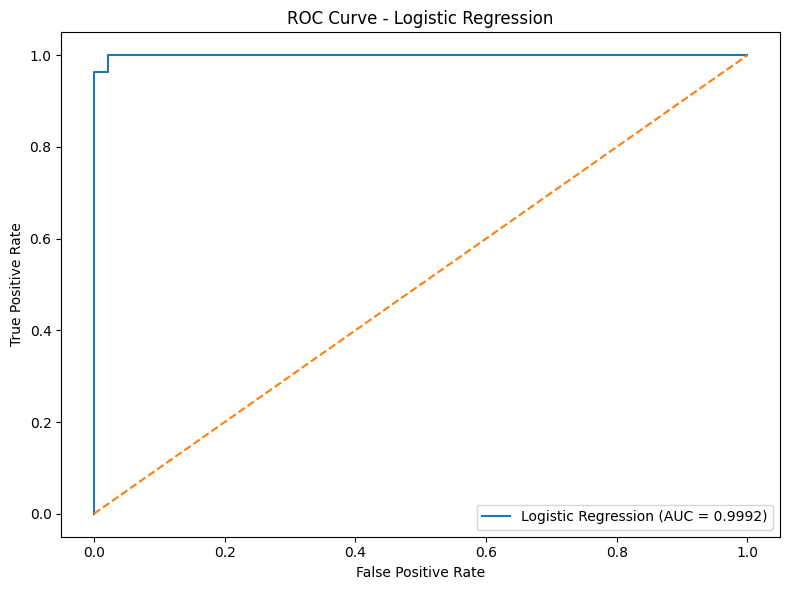


===== THRESHOLD SENSITIVITY TABLE ===%%
   Threshold  Precision    Recall        F1
0        0.3   0.949153  1.000000  0.973913
1        0.4   0.965517  1.000000  0.982456
2        0.5   0.982456  1.000000  0.991150
3        0.6   0.982456  1.000000  0.991150
4        0.7   1.000000  0.964286  0.981818

Best threshold by F1-score: 0.5

===== LOGISTIC REGULARIZATION COMPARISON ===%%
                          Model  Precision    Recall        F1      AUC
0   Logistic Regression (C=1.0)   0.982456  1.000000  0.991150  0.99924
1  Logistic Regression (C=0.01)   0.964912  0.982143  0.973451  0.99810

===== BOOTSTRAP AUC DIFFERENCE RESULTS ===%%
Mean AUC difference (C=1.0 - C=0.01): 0.0010027674217520158
95% CI lower: -0.000773820739903297
95% CI upper: 0.00455927051671734

All outputs saved successfully in the outputs/ folder.


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_score, recall_score, f1_score
)

# -------------------------------------------------
# 1. Create output folders
# -------------------------------------------------
os.makedirs("outputs", exist_ok=True)

# -------------------------------------------------
# 2. Load cleaned dataset
# -------------------------------------------------
# Corrected URL to fetch raw CSV data from GitHub
df = pd.read_csv("https://raw.githubusercontent.com/NarutoxMessi/Capstone-Project/data/cleaned_data.csv")   # Change path if needed
print("Dataset shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

# -------------------------------------------------
# 3. Define labels and feature matrix
# -------------------------------------------------
# Regression target
y_reg = df["close"].copy()

# Classification target (binary)
y_clf = (df["close"] > df["close"].median()).astype(int)

# Feature matrix:
# Drop target close, drop adj_close to avoid leakage,
# drop raw date because it is a raw string date field.
X = df.drop(columns=["close", "adj_close", "date"]).copy()

print("\nFeature columns used:")
print(X.columns.tolist())

# -------------------------------------------------
# 4. Encode categorical columns
# -------------------------------------------------
# Ordinal encoding for volume_category
# Natural order assumed: Low < Medium < High
if "volume_category" in X.columns:
    volume_map = {"Low": 0, "Medium": 1, "High": 2}
    X["volume_category"] = X["volume_category"].map(volume_map)

# One-hot encoding for nominal columns
categorical_nominal = []
for col in ["ticker", "day_name"]:
    if col in X.columns:
        categorical_nominal.append(col)

X = pd.get_dummies(X, columns=categorical_nominal, drop_first=True)

print("\nEncoded feature shape:", X.shape)
print("\nEncoded feature columns:")
print(X.columns.tolist())

# -------------------------------------------------
# 5. Train-test split
# -------------------------------------------------
# Use same split indices for both regression and classification
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Split classification target using same random_state
# Since the split should align with X rows, use indices from X_train/X_test
y_clf_train = y_clf.loc[X_train.index]
y_clf_test = y_clf.loc[X_test.index]

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# -------------------------------------------------
# 6. Leak-free scaling
# -------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on training data
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier coefficient interpretation
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# =================================================
# REGRESSION SECTION
# =================================================

# -------------------------------------------------
# 7. Linear Regression
# -------------------------------------------------
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled_df, y_reg_train)

y_pred_reg = lin_reg.predict(X_test_scaled_df)

mse_lr = mean_squared_error(y_reg_test, y_pred_reg)
r2_lr = r2_score(y_reg_test, y_pred_reg)

print("\n===== LINEAR REGRESSION RESULTS ===%%")
print("MSE :", mse_lr)
print("R^2 :", r2_lr)

# Coefficients with feature names
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lin_reg.coef_,
    "Abs_Coefficient": np.abs(lin_reg.coef_)
}).sort_values(by="Abs_Coefficient", ascending=False)

print("\nLinear Regression Coefficients:")
print(coef_df[["Feature", "Coefficient"]])

top3_features = coef_df.head(3)
print("\nTop 3 features by absolute coefficient:")
print(top3_features[["Feature", "Coefficient"]])

coef_df.to_csv("outputs/linear_regression_coefficients.csv", index=False)

# -------------------------------------------------
# 8. Ridge Regression
# -------------------------------------------------
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_scaled_df, y_reg_train)

y_pred_ridge = ridge_reg.predict(X_test_scaled_df)

mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge = r2_score(y_reg_test, y_pred_ridge)

print("\n===== RIDGE REGRESSION RESULTS ===%%")
print("MSE :", mse_ridge)
print("R^2 :", r2_ridge)

ridge_compare = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression (alpha=1.0)"],
    "MSE": [mse_lr, mse_ridge],
    "R2": [r2_lr, r2_ridge]
})

print("\nRegression comparison table:")
print(ridge_compare)
ridge_compare.to_csv("outputs/regression_comparison.csv", index=False)

# =================================================
# CLASSIFICATION SECTION
# =================================================

# -------------------------------------------------
# 9. Check class balance
# -------------------------------------------------
print("\n===== CLASS DISTRIBUTION BEFORE HANDLING ===%%")
class_counts_before = y_clf_train.value_counts()
print(class_counts_before)

minority_ratio = class_counts_before.min() / class_counts_before.sum()

# If minority class < 35%, use class_weight='balanced'
# Else use standard logistic regression
use_balanced = minority_ratio < 0.35

if use_balanced:
    print("\nClass imbalance detected. Using class_weight='balanced'.")
else:
    print("\nClass distribution is reasonably balanced. Using default class weights.")

# -------------------------------------------------
# 10. Logistic Regression baseline (C=1.0)
# -------------------------------------------------
if use_balanced:
    log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
else:
    log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_scaled_df, y_clf_train)

y_pred_clf = log_reg.predict(X_test_scaled_df)
y_proba_clf = log_reg.predict_proba(X_test_scaled_df)[:, 1]

# -------------------------------------------------
# 11. Classification metrics
# -------------------------------------------------
cm = confusion_matrix(y_clf_test, y_pred_clf)
report = classification_report(y_clf_test, y_pred_clf, output_dict=True)
report_text = classification_report(y_clf_test, y_pred_clf)

accuracy = report["accuracy"]
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

auc_baseline = roc_auc_score(y_clf_test, y_proba_clf)

print("\n===== LOGISTIC REGRESSION RESULTS (C=1.0) ===%%")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report_text)
print("AUC:", auc_baseline)

# Save classification report
with open("outputs/classification_report_baseline.txt", "w") as f:
    f.write("Confusion Matrix:\n")
    f.write(str(cm))
    f.write("\n\nClassification Report:\n")
    f.write(report_text)
    f.write(f"\nAUC: {auc_baseline:.4f}\n")

# -------------------------------------------------
# 12. ROC Curve
# -------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_clf_test, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_baseline:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("outputs/roc_curve_baseline.png", dpi=300)
plt.show()

# -------------------------------------------------
# 13. Decision-threshold sensitivity (0.30 to 0.70)
# -------------------------------------------------
threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.10):
    preds_thresh = (y_proba_clf >= threshold).astype(int)
    p = precision_score(y_clf_test, preds_thresh, zero_division=0)
    r = recall_score(y_clf_test, preds_thresh, zero_division=0)
    f = f1_score(y_clf_test, preds_thresh, zero_division=0)
    threshold_results.append([round(threshold, 2), p, r, f])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

print("\n===== THRESHOLD SENSITIVITY TABLE ===%%")
print(threshold_df)

threshold_df.to_csv("outputs/threshold_sensitivity.csv", index=False)

best_threshold_row = threshold_df.loc[threshold_df["F1"].idxmax()]
best_threshold = best_threshold_row["Threshold"]

print("\nBest threshold by F1-score:", best_threshold)

# -------------------------------------------------
# 14. Strong regularization Logistic Regression (C=0.01)
# -------------------------------------------------
if use_balanced:
    log_reg_strong = LogisticRegression(
        C=0.01, max_iter=1000, class_weight='balanced', random_state=42
    )
else:
    log_reg_strong = LogisticRegression(
        C=0.01, max_iter=1000, random_state=42
    )

log_reg_strong.fit(X_train_scaled_df, y_clf_train)

y_pred_strong = log_reg_strong.predict(X_test_scaled_df)
y_proba_strong = log_reg_strong.predict_proba(X_test_scaled_df)[:, 1]

precision_strong = precision_score(y_clf_test, y_pred_strong, zero_division=0)
recall_strong = recall_score(y_clf_test, y_pred_strong, zero_division=0)
f1_strong = f1_score(y_clf_test, y_pred_strong, zero_division=0)
auc_strong = roc_auc_score(y_clf_test, y_proba_strong)

regularization_compare = pd.DataFrame({
    "Model": ["Logistic Regression (C=1.0)", "Logistic Regression (C=0.01)"],
    "Precision": [precision, precision_strong],
    "Recall": [recall, recall_strong],
    "F1": [f1, f1_strong],
    "AUC": [auc_baseline, auc_strong]
})

print("\n===== LOGISTIC REGULARIZATION COMPARISON ===%%")
print(regularization_compare)

regularization_compare.to_csv("outputs/logistic_regularization_comparison.csv", index=False)

# -------------------------------------------------
# 15. Bootstrap confidence interval for AUC difference
# -------------------------------------------------
# AUC difference = AUC(C=1.0) - AUC(C=0.01)
np.random.seed(42)

y_test_array = np.array(y_clf_test)
proba_base_array = np.array(y_proba_clf)
proba_strong_array = np.array(y_proba_strong)

auc_diffs = []

for _ in range(500):
    idx = np.random.choice(len(y_test_array), size=len(y_test_array), replace=True)
    y_boot = y_test_array[idx]
    proba_base_boot = proba_base_array[idx]
    proba_strong_boot = proba_strong_array[idx]

    # Skip samples containing only one class
    if len(np.unique(y_boot)) < 2:
        continue

    auc_base_boot = roc_auc_score(y_boot, proba_base_boot)
    auc_strong_boot = roc_auc_score(y_boot, proba_strong_boot)
    auc_diffs.append(auc_base_boot - auc_strong_boot)

auc_diffs = np.array(auc_diffs)

mean_auc_diff = auc_diffs.mean()
ci_lower = np.percentile(auc_diffs, 2.5)
ci_upper = np.percentile(auc_diffs, 97.5)

print("\n===== BOOTSTRAP AUC DIFFERENCE RESULTS ===%%")
print("Mean AUC difference (C=1.0 - C=0.01):", mean_auc_diff)
print("95% CI lower:", ci_lower)
print("95% CI upper:", ci_upper)

bootstrap_summary = pd.DataFrame({
    "Metric": ["Mean AUC Difference", "95% CI Lower", "95% CI Upper"],
    "Value": [mean_auc_diff, ci_lower, ci_upper]
})

bootstrap_summary.to_csv("outputs/bootstrap_auc_difference_summary.csv", index=False)

# -------------------------------------------------
# 16. Save summary metrics for README use
# -------------------------------------------------
summary_metrics = pd.DataFrame({
    "Metric": [
        "Linear Regression MSE",
        "Linear Regression R2",
        "Ridge Regression MSE",
        "Ridge Regression R2",
        "Baseline Logistic Accuracy",
        "Baseline Logistic Precision",
        "Baseline Logistic Recall",
        "Baseline Logistic F1",
        "Baseline Logistic AUC",
        "Strong Reg Logistic Precision",
        "Strong Reg Logistic Recall",
        "Strong Reg Logistic F1",
        "Strong Reg Logistic AUC",
        "Best Threshold by F1",
        "Mean AUC Difference",
        "Bootstrap 95% CI Lower",
        "Bootstrap 95% CI Upper"
    ],
    "Value": [
        mse_lr, r2_lr,
        mse_ridge, r2_ridge,
        accuracy, precision, recall, f1, auc_baseline,
        precision_strong, recall_strong, f1_strong, auc_strong,
        best_threshold,
        mean_auc_diff, ci_lower, ci_upper
    ]
})

summary_metrics.to_csv("outputs/part2_summary_metrics.csv", index=False)

print("\nAll outputs saved successfully in the outputs/ folder.")